**DAT341/DIT867 Applied Machine Learning - PA2 (ML WorkFlow and Decision Trees)**

**PA2 - Group8 - Gokula Gopala , Madhumitha Selvaraj, Manjula Vaitheeswaran**

**Task1: Working with a dataset with categorical features**

In [2]:

import pandas as pd
from sklearn.feature_extraction import DictVectorizer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline

# --- Step 1: Reading the data ---
# Load training and test data
train_df = pd.read_csv("adult_train.csv")
test_df = pd.read_csv("adult_test.csv")

# Split into input features (X) and target (y)
X_train = train_df.drop(columns=["target"])
Y_train = train_df["target"]
X_test = test_df.drop(columns=["target"])
Y_test = test_df["target"]

# Convert rows to dictionaries
X_train_dicts = X_train.to_dict(orient="records")
X_test_dicts = X_test.to_dict(orient="records")

# Create and apply DictVectorizer
dv = DictVectorizer()

X_train_encoded = dv.fit_transform(X_train_dicts)
X_test_encoded = dv.transform(X_test_dicts)

# Train
clf = GradientBoostingClassifier(n_estimators=100, random_state=0)
clf.fit(X_train_encoded, Y_train)

# Evaluate on training data (optional)
cv_scores = cross_val_score(clf, X_train_encoded, Y_train, cv=5, scoring="accuracy")
print("CV accuracy:", cv_scores.mean())

# Evaluate on test data
test_pred = clf.predict(X_test_encoded)
print("Test accuracy:", accuracy_score(Y_test, test_pred))

pipeline = make_pipeline(
    DictVectorizer(),
    GradientBoostingClassifier()
)
# Fit pipeline (DictVectorizer + classifier)
pipeline.fit(X_train_dicts, Y_train)

# Predict
train_pred_pipe = pipeline.predict(X_train_dicts)
test_pred_pipe = pipeline.predict(X_test_dicts)

# Accuracy
print("Training accuracy (pipeline):", accuracy_score(Y_train, train_pred_pipe))
print("Test accuracy (pipeline):", accuracy_score(Y_test, test_pred_pipe))



CV accuracy: 0.8656675592304335
Test accuracy: 0.871199557766722
Training accuracy (pipeline): 0.868769386689598
Test accuracy (pipeline): 0.871199557766722


-The datasets are loaded using Pandas and each dataset is splitted into input features(X) and Output (Y-target column).
-In the categorical feature handling, the input feature matrices were converted into lists of Python dictionaries using DataFrame.to_dict(orient="records")
-One-hot encoding via DictVectorizer is applied, where the dv used fit(On training data) to map the feature values to the columns and used transform to apply the mapping in the test data.
-GradientBoostingClassifier was selected and it is trained on the one-hot encoded training features.
-Model performance was evaluated by computing the Cross-validation score on the training data and Accuracy score on the test data. 
-Pipeline was created using DictVectorizer for one-hot encoding and GradientBoostingClassifier for classification.
-The pipeline automatically applied feature encoding before training the classifier.The pipeline's accuracy results are consistent with the manually encoded workflow, showing the correctness of the preprocessing and modelling.

CV accuracy: 0.8656675592304335
Test accuracy: 0.871199557766722
Training accuracy (pipeline): 0.868769386689598
Test accuracy (pipeline): 0.8711381364781033

**Task 2: Decision trees and random forests**

Decision Tree Accuracies:
Max Depth | Train Acc | Test Acc
        1 | 0.7592   | 0.7638
        2 | 0.8282   | 0.8307
        3 | 0.8439   | 0.8448
        4 | 0.8439   | 0.8448
        5 | 0.8520   | 0.8523
        6 | 0.8571   | 0.8575
        7 | 0.8584   | 0.8569
        8 | 0.8606   | 0.8569
        9 | 0.8639   | 0.8587
       10 | 0.8694   | 0.8611
       11 | 0.8738   | 0.8602
       12 | 0.8779   | 0.8584
       13 | 0.8842   | 0.8523
       14 | 0.8900   | 0.8503
       15 | 0.8974   | 0.8492
       16 | 0.9034   | 0.8433
       17 | 0.9103   | 0.8413
       18 | 0.9155   | 0.8406
       19 | 0.9221   | 0.8356
       20 | 0.9280   | 0.8333
       21 | 0.9331   | 0.8311
       22 | 0.9384   | 0.8291
       23 | 0.9430   | 0.8288
       24 | 0.9468   | 0.8251
       25 | 0.9503   | 0.8248
       26 | 0.9540   | 0.8224
       27 | 0.9570   | 0.8203
       28 | 0.9596   | 0.8208
       29 | 0.9618   | 0.8199
       30 | 0.9638   | 0.8208


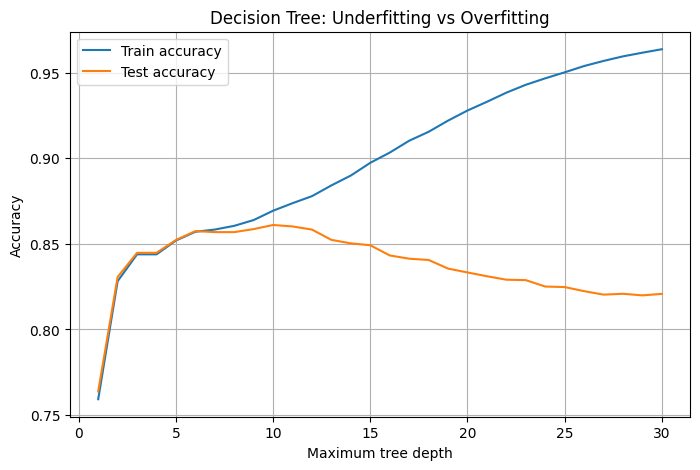

In [ ]:
#DecisionTreeClassifier
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction import DictVectorizer
from sklearn.tree import DecisionTreeClassifier

# --- Convert DataFrames to list of dictionaries ---
X_train_dicts = X_train.to_dict('records')
X_test_dicts = X_test.to_dict('records')

max_depths = range(1, 31)

dt_train_acc = []
dt_test_acc = []

for depth in max_depths:
    pipeline = make_pipeline(
        DictVectorizer(sparse=False),
        DecisionTreeClassifier(
            max_depth=depth,
            random_state=42
        )
    )

    pipeline.fit(X_train_dicts, Y_train)

    train_acc = pipeline.score(X_train_dicts, Y_train)
    test_acc = pipeline.score(X_test_dicts, Y_test)

    dt_train_acc.append(train_acc)
    dt_test_acc.append(test_acc)

print("Decision Tree Accuracies:")
print("Max Depth | Train Acc | Test Acc")
for depth, train_a, test_a in zip(max_depths, dt_train_acc, dt_test_acc):
    print(f"{depth:9} | {train_a:.4f}   | {test_a:.4f}")

#Plot: Decision Tree
plt.figure(figsize=(8, 5))
plt.plot(max_depths, dt_train_acc, label="Train accuracy")
plt.plot(max_depths, dt_test_acc, label="Test accuracy")
plt.xlabel("Maximum tree depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Underfitting vs Overfitting")
plt.legend()
plt.grid(True)
plt.show()


Random Forest with n_estimators = 1
Max Depth | Train Acc | Test Acc | Train Time (s)
        1 | 0.8026   | 0.8049  | 0.20
        2 | 0.8026   | 0.8049  | 0.18
        3 | 0.8026   | 0.8049  | 0.18
        4 | 0.8190   | 0.8194  | 0.18
        5 | 0.8190   | 0.8192  | 0.17
        6 | 0.8217   | 0.8221  | 0.17
        7 | 0.8299   | 0.8296  | 0.17
        8 | 0.8319   | 0.8307  | 0.17
        9 | 0.8360   | 0.8339  | 0.17
       10 | 0.8471   | 0.8466  | 0.18
       11 | 0.8517   | 0.8441  | 0.18
       12 | 0.8264   | 0.8176  | 0.17
       13 | 0.8448   | 0.8354  | 0.17
       14 | 0.8494   | 0.8378  | 0.17
       15 | 0.8590   | 0.8431  | 0.18
       16 | 0.8607   | 0.8409  | 0.18
       17 | 0.8667   | 0.8458  | 0.18
       18 | 0.8661   | 0.8410  | 0.18
       19 | 0.8762   | 0.8456  | 0.18
       20 | 0.8772   | 0.8461  | 0.18
       21 | 0.8785   | 0.8429  | 0.18
       22 | 0.8733   | 0.8422  | 0.18
       23 | 0.8829   | 0.8378  | 0.18
       24 | 0.8836   | 0.8353  | 0.18
 

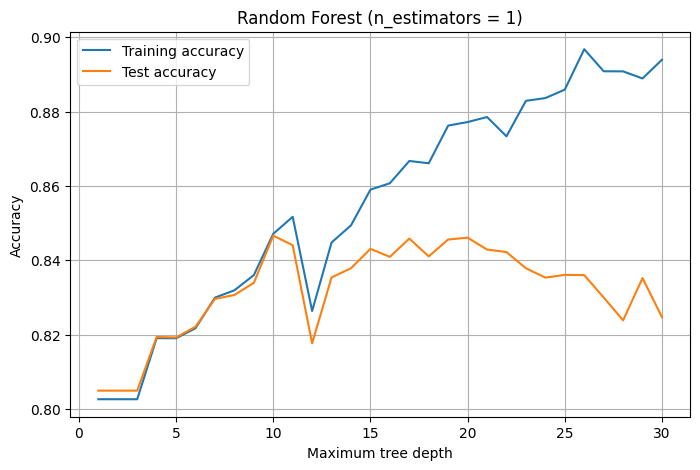

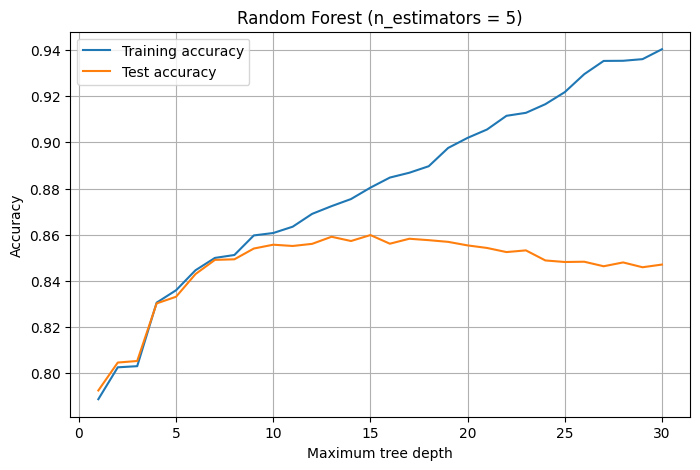

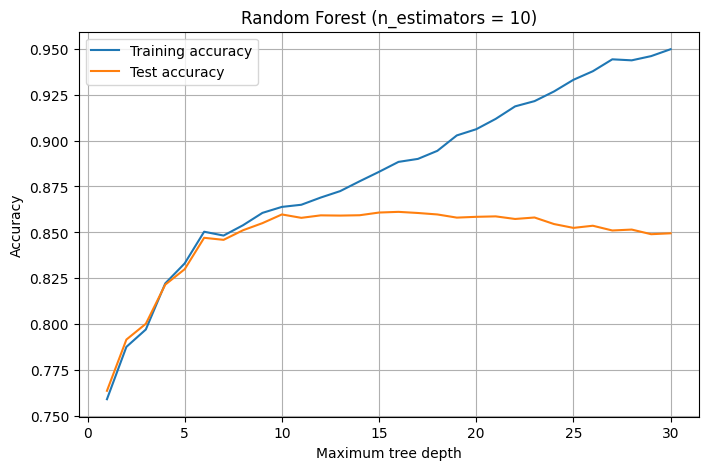

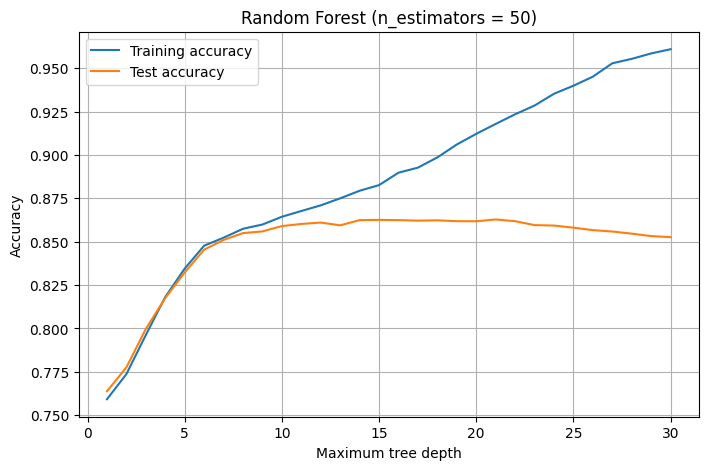

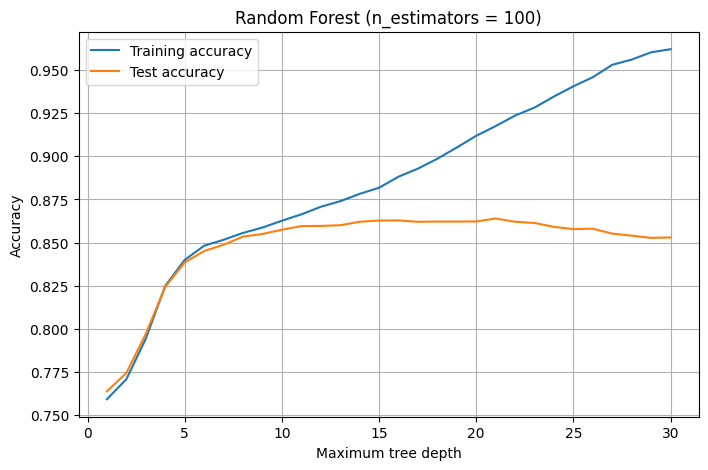

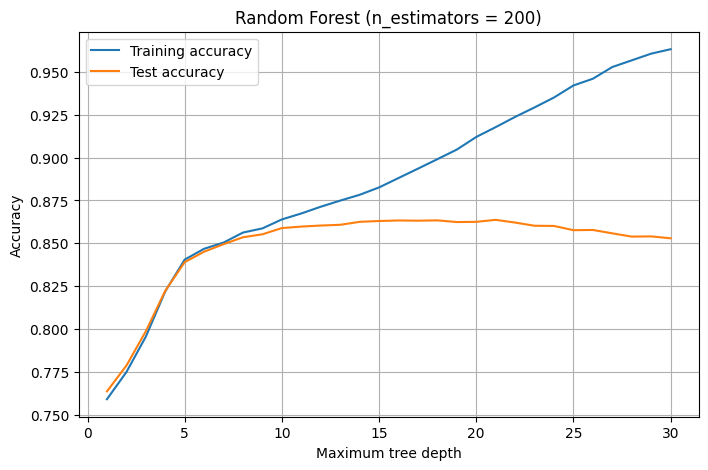

In [6]:
#Random Forest — Effect of Ensemble Size
n_estimators_list = [1, 5, 10, 50, 100, 200]
rf_results = {}
for n_estimators in n_estimators_list:
    train_acc = []
    test_acc = []
    train_time = []

    for depth in max_depths:
        pipeline = make_pipeline(
            DictVectorizer(sparse=False),
            RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=depth,
                n_jobs=-1,
                random_state=42
            )
        )

        start = time.time()
        pipeline.fit(X_train_dicts, Y_train)
        elapsed = time.time() - start

        train_acc.append(
            pipeline.score(X_train_dicts, Y_train)
        )
        test_acc.append(
            pipeline.score(X_test_dicts, Y_test)
        )
        train_time.append(elapsed)

    rf_results[n_estimators] = {
        "train_acc": train_acc,
        "test_acc": test_acc,
        "train_time": train_time
    }
# Print results
for n_estimators, results in rf_results.items():
    print(f"\nRandom Forest with n_estimators = {n_estimators}")
    print("Max Depth | Train Acc | Test Acc | Train Time (s)")
    for depth, train_a, test_a, t_time in zip(max_depths, results["train_acc"], results["test_acc"], results["train_time"]):
        print(f"{depth:9} | {train_a:.4f}   | {test_a:.4f}  | {t_time:.2f}")

#Plot Random Forest Accuracy Curves
for n_estimators in n_estimators_list:
    plt.figure(figsize=(8, 5))
    plt.plot(
        max_depths,
        rf_results[n_estimators]["train_acc"],
        label="Training accuracy"
    )
    plt.plot(
        max_depths,
        rf_results[n_estimators]["test_acc"],
        label="Test accuracy"
    )
    plt.xlabel("Maximum tree depth")
    plt.ylabel("Accuracy")
    plt.title(f"Random Forest (n_estimators = {n_estimators})")
    plt.legend()
    plt.grid(True)
    plt.show()



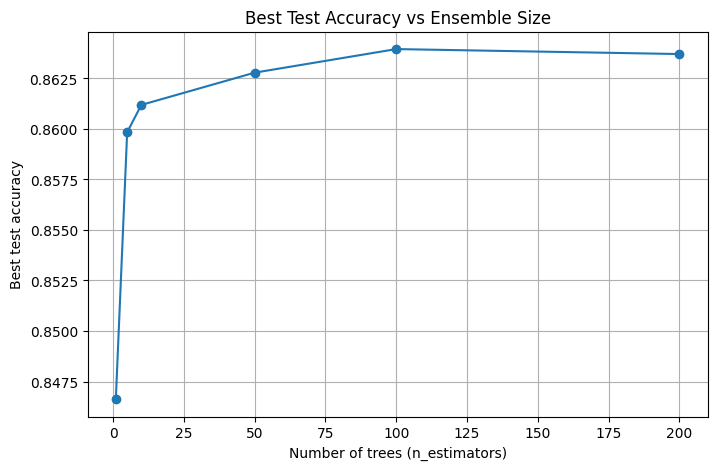

In [7]:
#Best Test Accuracy vs Ensemble Size
best_test_acc = []

for n_estimators in n_estimators_list:
    best_test_acc.append(
        max(rf_results[n_estimators]["test_acc"])
    )

plt.figure(figsize=(8, 5))
plt.plot(n_estimators_list, best_test_acc, marker='o')
plt.xlabel("Number of trees (n_estimators)")
plt.ylabel("Best test accuracy")
plt.title("Best Test Accuracy vs Ensemble Size")
plt.grid(True)
plt.show()


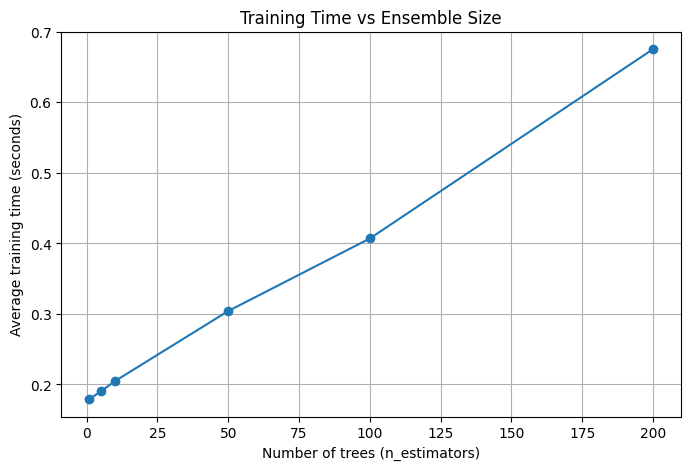

In [8]:
#Training Time vs Ensemble Size
avg_train_time = []

for n_estimators in n_estimators_list:
    avg_train_time.append(
        np.mean(rf_results[n_estimators]["train_time"])
    )

plt.figure(figsize=(8, 5))
plt.plot(n_estimators_list, avg_train_time, marker='o')
plt.xlabel("Number of trees (n_estimators)")
plt.ylabel("Average training time (seconds)")
plt.title("Training Time vs Ensemble Size")
plt.grid(True)
plt.show()


**1.What's the difference between the curve for a decision tree and for a random forest with an ensemble size of 1, and why do we see this difference?**

A Random Forest with only one tree is not exactly the same as a single decision tree. Even though there is only one tree, the random forest chooses splits using a random subset of features and trains on a bootstrap sample of the data. Because of this randomness, the accuracy curve of the random forest may be slightly different from a normal decision tree. The tree may also generalize a little better or worse depending on the random sample, so the curves are not identical.

**What happens with the curve for random forests as the ensemble size grows?**

As the ensemble size grows, the curves become much smoother. For a single tree, the test accuracy often fluctuates or drops off sharply after a certain depth (overfitting). With more trees, the "gap" between training and testing accuracy stabilizes. The forest averages out the individual errors of each tree, which prevents the model from being too sensitive to noise in the training set.

**What happens with the best observed test set accuracy as the ensemble size grows?**

The best test set accuracy generally improves as we add more trees, but only up to a certain point. I noticed a big jump in performance moving from 1 tree to 10 trees, but the improvement from 50 to 100 trees was much smaller. This shows that adding more estimators helps the model reach a higher performance plateau, but there are diminishing returns eventually.

**What happens with the training time as the ensemble size grows?**

The training time increases linearly with the number of trees. Training 100 trees takes significantly longer than training one. However, by using n_jobs=-1, I was able to distribute the work across my CPU cores, which kept the "wall-clock" time manageable. Without parallel processing, the training time would be a major bottleneck as $n\_estimators$ increases.

**Task 3:Feature importances in random forest classifiers**

In [ ]:
#"Task 3:Feature Important Analysis:"

print("\n Training Random Forest for Feature Importance Analysis...")
print(f"   Using best parameters: n_estimators=100, max_depth=20")

best_rf_pipeline = make_pipeline(
    DictVectorizer(sparse = False),
    RandomForestClassifier(n_estimators=100, max_depth=20,random_state=42,n_jobs = -1)
)
best_rf_pipeline.fit(X_train_dicts , Y_train)

train_accuracy = best_rf_pipeline.score(X_train_dicts, Y_train)
test_accuracy = best_rf_pipeline.score(X_test_dicts, Y_test)
print(f"\n Model Trained Successfully!")
print(f"   Training Accuracy: {train_accuracy:.4f}")
print(f"   Test Accuracy: {test_accuracy:.4f}")

print("\n Extracting Feature Importances...\n")

vectorizer = best_rf_pipeline.steps[0][1]
rf_model = best_rf_pipeline.steps[1][1]

feature_names = vectorizer.feature_names_ # names from vectorizer
feature_importances = rf_model.feature_importances_#importance from Random Forest
print(f" Total features: {len(feature_names)}")
print(f" Feature importances extracted: {len(feature_importances)} values")

assert len(feature_names) == len(feature_importances)

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
feature_importance_df.reset_index(drop=True, inplace=True)
print(f"\n Feature importance DataFrame created and sorted!")
print(f"   Shape: {feature_importance_df.shape}")

print("\n Top 20 Features by Importance:\n")
print(f"{'Rank':<6} {'Feature':<35} {'Importance':<12} {'% of Total':<12}")
print("-" * 70)

total_importance = feature_importances.sum()

for idx in range(20):
    rank = idx + 1
    feature = feature_importance_df.iloc[idx]['Feature']
    importance = feature_importance_df.iloc[idx]['Importance']
    percentage = (importance / total_importance) * 100

    print(f"{rank:<6} {feature:<35} {importance:<12.6f} {percentage:<12.2f}%")

print("\n" + "=" * 70)
print(" IMPORTANCE DISTRIBUTION STATISTICS")
print("=" * 70)

top_5_sum = feature_importance_df.head(5)['Importance'].sum()
top_10_sum = feature_importance_df.head(10)['Importance'].sum()
top_20_sum = feature_importance_df.head(20)['Importance'].sum()

print(f"\nTop 5 features account for:  {(top_5_sum/total_importance)*100:.2f}% of total importance")
print(f"Top 10 features account for: {(top_10_sum/total_importance)*100:.2f}% of total importance")
print(f"Top 20 features account for: {(top_20_sum/total_importance)*100:.2f}% of total importance")





 Training Random Forest for Feature Importance Analysis...
   Using best parameters: n_estimators=100, max_depth=20

 Model Trained Successfully!
   Training Accuracy: 0.9119
   Test Accuracy: 0.8622

 Extracting Feature Importances...

 Total features: 107
 Feature importances extracted: 107 values

 Feature importance DataFrame created and sorted!
   Shape: (107, 2)

 Top 20 Features by Importance:

Rank   Feature                             Importance   % of Total  
----------------------------------------------------------------------
1      capital-gain                        0.146396     14.64       %
2      age                                 0.106729     10.67       %
3      marital-status=Married-civ-spouse   0.089079     8.91        %
4      education-num                       0.086936     8.69        %
5      relationship=Husband                0.077666     7.77        %
6      hours-per-week                      0.076718     7.67        %
7      capital-loss               

WHY these features are important:
1. capital-gain (Importance: 0.1464, 14.64%) strongly indicate wealth/high earners
2. age (Importance: 0.1067, 10.67%) strong predictor - older workers typically earn more due to experience
3. marital-status=Married-civ-spouse (Importance: 0.0891, 8.91%) correlates with dual-income households and stability
4. education-num (Importance: 0.0869, 8.69%) directly correlate with earning potential
5. relationship=Husband (Importance: 0.0777, 7.77%) affects household income and work patterns
6. hours-per-week (Importance: 0.0767, 7.67%)full-time+ workers typically earn more
7. capital-loss (Importance: 0.0389, 3.89%)indicate investments, correlating with higher income
8. marital-status=Never-married (Importance: 0.0346, 3.46%) correlates with dual-income households and stability
9. occupation=Exec-managerial (Importance: 0.0249, 2.49%) have different earning potentials
10. occupation=Prof-specialty (Importance: 0.0221, 2.21%) have different earning potentials

Alternative Methods for Computing Feature Importance:

While tree-based feature importance (Gini/Information Gain) is useful, it has limitations:
1. Biased toward high-cardinality features:
2. Ignores feature interactions
3. Not robust to correlated features
4. No direction information

Alternative Methods:

 1. Permutation Importance
- Shuffle one feature's values randomly
- Measure drop in model accuracy
- Larger drop = more important feature
2. SHAP Values (SHapley Additive exPlanations)
- Based on game theory (Shapley values)
- Calculates each feature's contribution to every prediction
- Provides both magnitude AND direction
3. Partial Dependence Plots (PDP)
- Shows the marginal effect of one feature on predictions
- Plots feature value vs predicted outcome
- Visualizes the relationship direction
4. Drop-Column Importance
- Train model with all features → measure accuracy
- Train model without feature X → measure accuracy
- Importance = accuracy drop when X is removed


References:
- Parr et al. (2018): "Beware Default Random Forest Importances"
- Lundberg & Lee (2017): "A Unified Approach to Interpreting Model Predictions"
